File        : Kalibrasi-1.TXT
Jumlah data : 846,800 sampel
Durasi      : 0.000 - 423.399 s
Δt          : 0.000500 s
Strain min  : 7.392503e-05
Strain max  : 5.920000e-04


,time_s,strain,Comment
0,0.0000,0.000087,None
1,0.0005,0.000087,None
2,0.0010,0.000086,None
3,0.0015,0.000080,None
4,0.0020,0.000077,None


Sampling rate : 2000.0 Hz
LPF cutoff    : 10.0 Hz (Butterworth order 4)


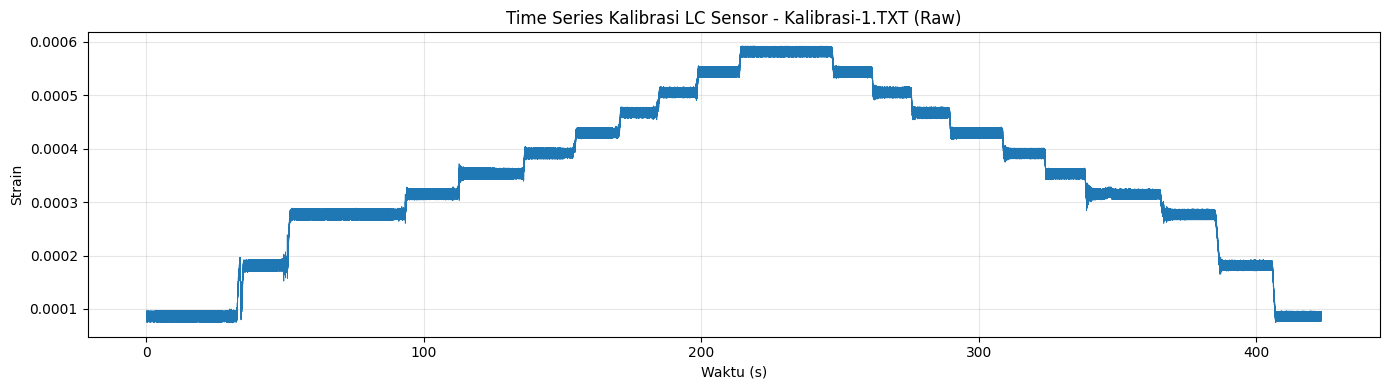

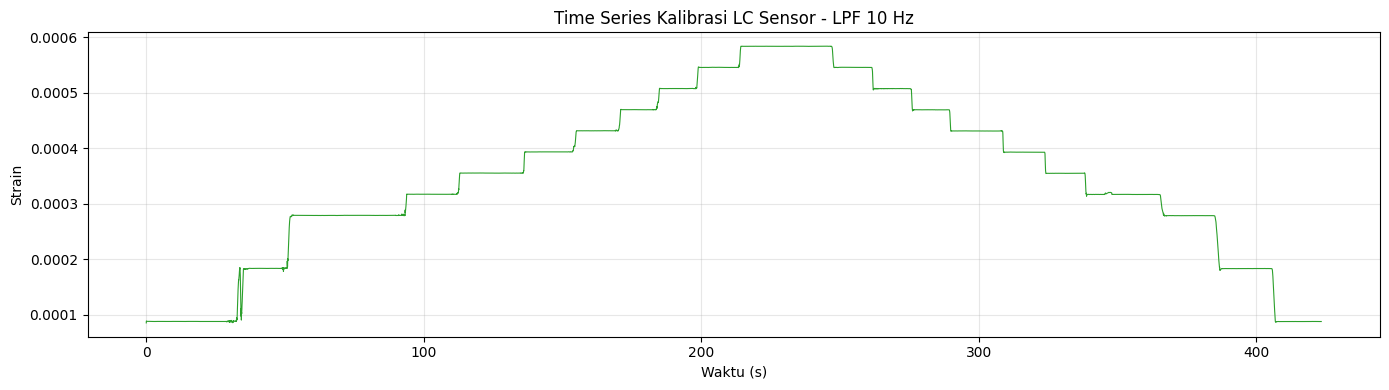

In [36]:
#Cell 0
# =============================================================================
# TUJUAN CELL INI:
# Membaca file data kalibrasi dari LabVIEW dan menampilkan sinyal strain
# terhadap waktu.
#
# Langkah yang dilakukan:
# 1. Baca file .TXT (format LabVIEW Measurement)
# 2. Tampilkan ringkasan data (jumlah sampel, durasi, dll.)
# 3. Plot sinyal mentah (raw)
# 4. Terapkan filter Low-Pass 10 Hz (LPF) untuk menghaluskan noise frekuensi tinggi
# 5. Plot sinyal setelah difilter
#
# Output penting:
# - DataFrame `df` dengan kolom: time_s, strain, strain_lpf
# - Kolom `strain_lpf` akan dipakai di cell berikutnya
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import butter, filtfilt  # butter=desain filter, filtfilt=terapkan tanpa delay fase

# Lokasi file data; coba path lokal dulu, lalu path dari root project
DATA_PATH = Path("Kalibrasi-1.TXT")
if not DATA_PATH.exists():
    DATA_PATH = Path("LC_A/04062026/Kalibrasi-1.TXT")

def load_labview_measurement(filepath: Path) -> pd.DataFrame:
    """Baca file LabVIEW Measurement (.TXT) dan ubah ke tabel pandas."""
    with open(filepath, "r", encoding="utf-8", errors="replace") as f:
        lines = f.readlines()

    # Cari baris header kolom data (dimulai dengan 'X_Value')
    header_idx = next(i for i, line in enumerate(lines) if line.startswith("X_Value"))
    column_names = lines[header_idx].strip().split("\t")

    data_rows = []
    for line in lines[header_idx + 1 :]:
        line = line.strip()
        if not line or line.startswith("***"):  # lewati baris kosong / penanda akhir header
            continue
        parts = line.split("\t")
        if len(parts) < 2:
            continue
        # Header punya 3 kolom tapi data kadang hanya 2 (kolom Comment kosong)
        row = parts + [None] * (len(column_names) - len(parts))
        data_rows.append(row[: len(column_names)])

    df = pd.DataFrame(data_rows, columns=column_names)
    df["X_Value"] = pd.to_numeric(df["X_Value"], errors="coerce")
    df["LC_A_Ring_2026_cDaq9237"] = pd.to_numeric(df["LC_A_Ring_2026_cDaq9237"], errors="coerce")
    df = df.dropna(subset=["X_Value", "LC_A_Ring_2026_cDaq9237"]).reset_index(drop=True)

    # Ubah nama kolom agar lebih mudah dipahami
    return df.rename(columns={
        "X_Value": "time_s",                        # waktu dalam detik
        "LC_A_Ring_2026_cDaq9237": "strain",        # pembacaan strain sensor
    })

# --- Muat data ke memori ---
df = load_labview_measurement(DATA_PATH)

# Tampilkan ringkasan singkat data
print(f"File        : {DATA_PATH}")
print(f"Jumlah data : {len(df):,} sampel")
print(f"Durasi      : {df['time_s'].iloc[0]:.3f} - {df['time_s'].iloc[-1]:.3f} s")
print(f"Δt          : {df['time_s'].diff().median():.6f} s")  # interval sampling
print(f"Strain min  : {df['strain'].min():.6e}")
print(f"Strain max  : {df['strain'].max():.6e}")
display(df.head())  # preview 5 baris pertama

# --- Filter Low-Pass 10 Hz ---
# Tujuan: buang noise/getaran frekuensi tinggi, pertahankan perubahan beban (lambat)
fs = 1.0 / df["time_s"].diff().median()  # frekuensi sampling (Hz), ~2000 Hz
fc_lpf = 10.0   # frekuensi potong filter: sinyal di atas 10 Hz dibuang
order = 4       # orde filter Butterworth (semakin tinggi, transisi semakin tajam)
b, a = butter(order, fc_lpf / (fs / 2), btype="low")  # normalisasi ke frekuensi Nyquist (fs/2)
df["strain_lpf"] = filtfilt(b, a, df["strain"].values)  # terapkan filter zero-phase

print(f"Sampling rate : {fs:.1f} Hz")
print(f"LPF cutoff    : {fc_lpf} Hz (Butterworth order {order})")

# --- Plot 1: sinyal mentah (belum difilter) ---
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df["time_s"], df["strain"], linewidth=0.5, color="#1f77b4")
ax.set_xlabel("Waktu (s)")
ax.set_ylabel("Strain")
ax.set_title("Time Series Kalibrasi LC Sensor - Kalibrasi-1.TXT (Raw)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Plot 2: sinyal setelah LPF 10 Hz (lebih halus) ---
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df["time_s"], df["strain_lpf"], linewidth=0.8, color="#2ca02c")
ax.set_xlabel("Waktu (s)")
ax.set_ylabel("Strain")
ax.set_title("Time Series Kalibrasi LC Sensor - LPF 10 Hz")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Urutan beban (21 level): [0, 5, 10, 12, 14, 16, 18, 20, 22, 24, 26, 24, 22, 20, 18, 16, 14, 12, 10, 5, 0]

--- Hasil segmentasi (kondisi stabil, data LPF 10 Hz) ---


,load_kg,phase,t_start,t_end,t_stable_start,t_stable_end,duration_s,strain_mean,strain_std,n_samples
0,0,naik,0.00,32.7500,8.187500,24.562500,32.7500,0.000088,6.801013e-08,32751
1,5,naik,35.30,51.5500,39.362500,47.487500,16.2500,0.000184,5.337812e-08,16251
2,10,naik,51.55,93.9000,62.137500,83.312500,42.3500,0.000279,8.978285e-08,42351
3,12,naik,93.90,112.4500,98.537500,107.812500,18.5500,0.000317,7.083548e-08,18550
4,14,naik,112.45,136.0500,118.350000,130.150000,23.6000,0.000356,8.323007e-08,23600
5,16,naik,136.05,154.5500,140.675000,149.925000,18.5000,0.000394,6.717108e-08,18501
6,18,naik,154.55,170.1000,158.437500,166.212500,15.5500,0.000432,6.885863e-08,15551
7,20,naik,170.10,184.1000,173.600000,180.600000,14.0000,0.000470,5.869843e-08,14001
8,22,naik,184.10,198.0500,187.587500,194.562500,13.9500,0.000508,5.741349e-08,13951
9,24,naik,198.05,213.7000,201.962500,209.787500,15.6500,0.000546,9.172951e-08,15651


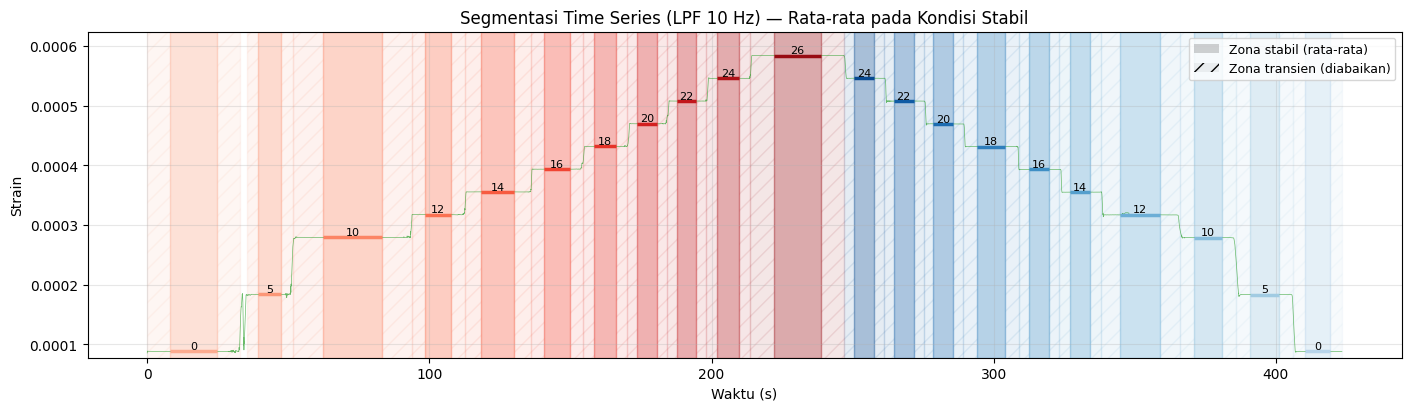

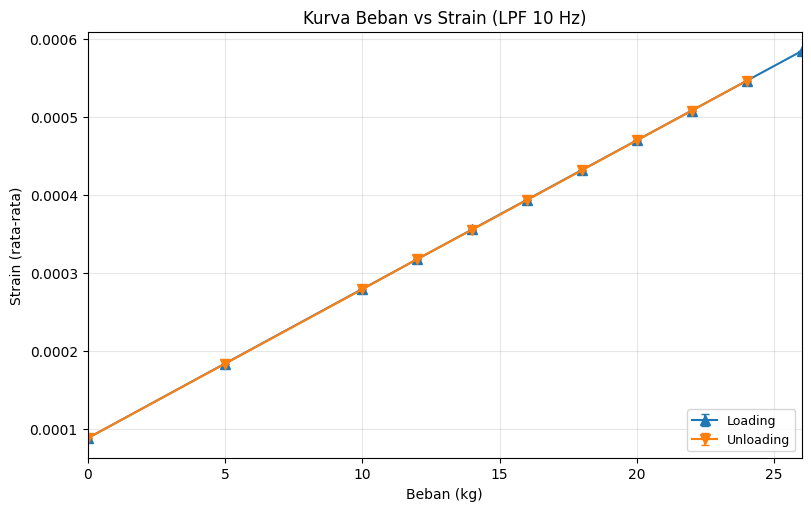

In [37]:
#Cell 1
# =============================================================================
# TUJUAN CELL INI:
# Membagi data time series menjadi segmen-segmen sesuai setiap level beban,
# lalu menghitung rata-rata strain pada kondisi stabil.
#
# Konsep pembebanan:
# - Beban dinaikkan bertahap: 0 -> 5 -> 10 -> 12 -> ... -> 26 kg
# - Kemudian diturunkan kembali ke 0 kg
#
# Langkah yang dilakukan:
# 1. Deteksi otomatis kapan beban berubah (dari perubahan sinyal strain)
# 2. Pada setiap segmen, ambil hanya bagian tengah yang sudah stabil
#    (bagian awal/akhir dibuang karena masih transien/creep)
# 3. Hitung rata-rata & simpangan baku strain per level beban
# 4. Plot segmentasi (zona stabil vs transien) dan kurva beban vs strain
#
# Output penting:
# - DataFrame `segments` (strain_mean, load_kg, phase, waktu segmen, dll.)
# =============================================================================

from scipy.signal import find_peaks

# Kolom strain yang dipakai: hasil filter LPF dari Cell 0
STRAIN_COL = "strain_lpf"

# --- Susun urutan beban yang dikenal dari protokol pengujian ---
# Setiap angka = tambahan beban (kg) pada langkah tersebut
LOAD_INCREMENTS = [5, 5, 2, 2, 2, 2, 2, 2, 2, 2]

loads_up = [0]  # mulai dari 0 kg
for inc in LOAD_INCREMENTS:
    loads_up.append(loads_up[-1] + inc)  # akumulasi beban saat naik

loads_down = []
c = loads_up[-1]  # mulai dari beban maksimum (26 kg)
for inc in reversed(LOAD_INCREMENTS):
    c -= inc
    loads_down.append(c)  # kurangi beban bertahap saat turun

LOAD_SEQUENCE = loads_up + loads_down  # total 21 level: 11 naik + 10 turun
print(f"Urutan beban ({len(LOAD_SEQUENCE)} level): {LOAD_SEQUENCE}")

# --- Parameter deteksi transisi & zona stabil ---
SMOOTH_WIN = 4000       # jendela smoothing ~2 detik (4000 sampel @ 2 kHz)
MIN_SEGMENT_S = 5.0     # abaikan segmen < 5 detik (terlalu pendek, masih transien)
STABLE_MARGIN = 0.25    # buang 25% awal & akhir segmen, ambil bagian tengah saja

# Haluskan sinyal untuk deteksi perubahan beban (bukan untuk perhitungan rata-rata)
df["strain_smooth"] = df[STRAIN_COL].rolling(
    SMOOTH_WIN, center=True, min_periods=SMOOTH_WIN // 2
).mean()

# Downsampling 1:100 agar deteksi puncak lebih cepat
ds = df.iloc[::100].dropna(subset=["strain_smooth"]).copy()
ds["d_smooth"] = ds["strain_smooth"].diff().abs()  # laju perubahan strain

# Cari puncak perubahan strain = titik saat beban ditambah/dikurangi
peaks, _ = find_peaks(
    ds["d_smooth"],
    height=ds["d_smooth"].quantile(0.90),  # hanya perubahan besar (top 10%)
    distance=50,  # minimal jarak antar puncak (hindari deteksi ganda)
)
trans_times = sorted(ds["time_s"].iloc[peaks].tolist())

# Batas segmen = titik transisi antar level beban
bounds = [df["time_s"].iloc[0]] + trans_times + [df["time_s"].iloc[-1]]
bounds = sorted(set(bounds))

raw_segments = []
for i in range(len(bounds) - 1):
    t_start, t_end = bounds[i], bounds[i + 1]
    duration = t_end - t_start
    if duration < MIN_SEGMENT_S:
        continue  # lewati segmen terlalu pendek

    # Hitung batas zona stabil (bagian tengah segmen)
    margin = max(1.0, STABLE_MARGIN * duration)
    t_stable_start = t_start + margin
    t_stable_end = t_end - margin
    mask = (df["time_s"] >= t_stable_start) & (df["time_s"] <= t_stable_end)
    stable = df.loc[mask]
    if len(stable) < 500:
        continue  # data zona stabil terlalu sedikit

    raw_segments.append({
        "t_start": t_start,
        "t_end": t_end,
        "t_stable_start": t_stable_start,
        "t_stable_end": t_stable_end,
        "duration_s": duration,
        "strain_mean": stable[STRAIN_COL].mean(),  # rata-rata strain zona stabil
        "strain_std": stable[STRAIN_COL].std(),    # variasi strain dalam zona stabil
        "n_samples": len(stable),
    })

segments = pd.DataFrame(raw_segments).reset_index(drop=True)

if len(segments) != len(LOAD_SEQUENCE):
    print(f"PERINGATAN: {len(segments)} segmen stabil vs {len(LOAD_SEQUENCE)} level beban")

# Pasangkan setiap segmen dengan level beban dan fase (naik/turun)
segments["load_kg"] = LOAD_SEQUENCE[: len(segments)]
segments["phase"] = ["naik"] * len(loads_up) + ["turun"] * len(loads_down)
segments["phase"] = segments["phase"][: len(segments)]

print("\n--- Hasil segmentasi (kondisi stabil, data LPF 10 Hz) ---")
display(segments[["load_kg", "phase", "t_start", "t_end", "t_stable_start", "t_stable_end",
                  "duration_s", "strain_mean", "strain_std", "n_samples"]])

# --- Plot 1: Segmentasi time series ---
fig, ax = plt.subplots(figsize=(14, 4), layout="constrained")

ax.plot(df["time_s"], df[STRAIN_COL], linewidth=0.5, alpha=0.7, color="#2ca02c", label="LPF 10 Hz")
colors_up = plt.cm.Reds(np.linspace(0.3, 0.9, len(loads_up)))    # warna merah = fase naik
colors_down = plt.cm.Blues(np.linspace(0.9, 0.3, len(loads_down)))  # warna biru = fase turun
seg_colors = list(colors_up) + list(colors_down)

for i, row in segments.iterrows():
    color = seg_colors[i] if i < len(seg_colors) else "gray"
    # Zona transien (garis miring) = data yang DIBUANG dari perhitungan rata-rata
    ax.axvspan(row["t_start"], row["t_stable_start"], alpha=0.10, color=color, hatch="//")
    ax.axvspan(row["t_stable_end"], row["t_end"], alpha=0.10, color=color, hatch="//")
    # Zona stabil (warna solid) = data yang DIPAKAI untuk rata-rata
    ax.axvspan(row["t_stable_start"], row["t_stable_end"], alpha=0.35, color=color)
    ax.hlines(
        row["strain_mean"], row["t_stable_start"], row["t_stable_end"],
        colors=color, linewidth=2.5,  # garis horizontal = nilai rata-rata strain
    )
    ax.text(
        (row["t_stable_start"] + row["t_stable_end"]) / 2, row["strain_mean"],
        f"{row['load_kg']:.0f}", ha="center", va="bottom", fontsize=8, clip_on=True,
    )

from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor="gray", alpha=0.35, label="Zona stabil (rata-rata)"),
    Patch(facecolor="gray", alpha=0.10, hatch="//", label="Zona transien (diabaikan)"),
]
ax.legend(handles=legend_handles, loc="upper right", fontsize=9)

ymin, ymax = df[STRAIN_COL].min(), df[STRAIN_COL].max()
ymargin = (ymax - ymin) * 0.08
ax.set_ylim(ymin - ymargin * 0.2, ymax + ymargin)
ax.set_xlabel("Waktu (s)")
ax.set_ylabel("Strain")
ax.set_title("Segmentasi Time Series (LPF 10 Hz) — Rata-rata pada Kondisi Stabil")
ax.grid(True, alpha=0.3)
plt.show()

# --- Plot 2: Kurva beban vs strain (naik dan turun terpisah) ---
fig, ax = plt.subplots(figsize=(8, 5), layout="constrained")

for phase, marker, lbl in [("naik", "^", "Loading"), ("turun", "v", "Unloading")]:
    sub = segments[segments["phase"] == phase]
    ax.errorbar(sub["load_kg"], sub["strain_mean"], yerr=sub["strain_std"],
                fmt=f"{marker}-", capsize=3, label=lbl, markersize=7)

ax.set_xlabel("Beban (kg)")
ax.set_ylabel("Strain (rata-rata)")
ax.set_xlim(0, 26)  # batas sumbu X sesuai beban maksimum
ax.set_title("Kurva Beban vs Strain (LPF 10 Hz)")
ax.legend(loc="lower right", fontsize=9)
ax.grid(True, alpha=0.3)
plt.show()


=== Model Regresi Linier (data LPF 10 Hz) ===
Y = m·X + c
Y (Kg)  = 52469.7474 · X (strain) + (-4.6492)
m (slope)     : 52,469.75 kg/strain
c (intercept) : -4.6492 kg
R²            : 0.999999
RMSE          : 0.0075 kg
p-value       : 2.12e-28


,load_kg,strain_mean,strain_std,load_pred_kg,residual_kg
0,0,0.000088,6.801013e-08,-0.015059,0.015059
1,5,0.000184,5.337812e-08,4.999660,0.000340
2,10,0.000279,8.978285e-08,10.007315,-0.007315
3,12,0.000317,7.083548e-08,12.007821,-0.007821
4,14,0.000356,8.323007e-08,14.007895,-0.007895
5,16,0.000394,6.717108e-08,16.006651,-0.006651
6,18,0.000432,6.885863e-08,18.004369,-0.004369
7,20,0.000470,5.869843e-08,20.000019,-0.000019
8,22,0.000508,5.741349e-08,21.995891,0.004109
9,24,0.000546,9.172951e-08,23.996452,0.003548


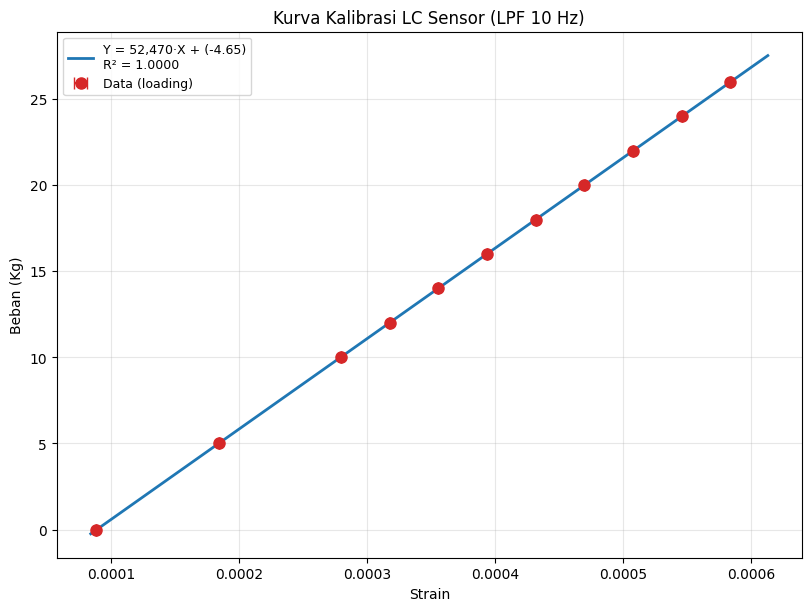


Koefisien tersimpan di dict CALIBRATION: {'m': np.float64(52469.74743426486), 'c': np.float64(-4.649189253380209), 'r2': np.float64(0.9999990428393178), 'rmse': np.float64(0.007495318188047118)}


In [38]:
#Cell 2
# =============================================================================
# TUJUAN CELL INI:
# Membuat model kalibrasi sederhana: Beban (kg) = f(Strain)
#
# Metode:
# - Hanya memakai data fase NAIK (loading), tanpa zero-offset
# - Regresi linier: Y = m·X + c
#   Y = beban (kg), X = strain, m = sensitivitas, c = intercept
#
# Output penting:
# - Koefisien m, c, R², RMSE
# - Dict `CALIBRATION` untuk dipakai menghitung beban dari strain
#
# Catatan: Cell 3 memakai metode yang lebih baik (zero-offset + rata-rata
# naik/turun). Cell 2 berguna sebagai perbandingan.
# =============================================================================

from scipy import stats

# Ambil hanya data fase naik (loading) — 11 titik dari 0 s/d 26 kg
cal = segments[segments["phase"] == "naik"].copy()
X = cal["strain_mean"].values   # variabel independen: strain
Y = cal["load_kg"].values       # variabel dependen: beban (kg)

# Hitung garis lurus terbaik yang menghubungkan strain dan beban
slope, intercept, r_value, p_value, std_err = stats.linregress(X, Y)
r_squared = r_value ** 2  # R²: seberapa baik garis cocok (1.0 = sempurna)

# Evaluasi model: prediksi vs aktual
cal["load_pred_kg"] = slope * cal["strain_mean"] + intercept  # beban prediksi dari model
cal["residual_kg"] = cal["load_kg"] - cal["load_pred_kg"]     # selisih aktual - prediksi
rmse = np.sqrt(np.mean(cal["residual_kg"] ** 2))              # akar error kuadrat rata-rata (kg)

print("=== Model Regresi Linier (data LPF 10 Hz) ===")
print(f"Y = m·X + c")
print(f"Y (Kg)  = {slope:.4f} · X (strain) + ({intercept:.4f})")
print(f"m (slope)     : {slope:,.2f} kg/strain")   # sensitivitas: berapa kg per unit strain
print(f"c (intercept) : {intercept:.4f} kg")        # offset beban saat strain = 0
print(f"R²            : {r_squared:.6f}")           # kualitas kecocokan model
print(f"RMSE          : {rmse:.4f} kg")             # rata-rata kesalahan prediksi
print(f"p-value       : {p_value:.2e}")             # signifikansi statistik (< 0.05 = signifikan)

display(cal[["load_kg", "strain_mean", "strain_std", "load_pred_kg", "residual_kg"]])

# --- Plot kurva kalibrasi ---
fig, ax = plt.subplots(figsize=(8, 6), layout="constrained")

# Titik data pengukuran dengan error bar (ketidakpastian strain)
ax.errorbar(
    cal["strain_mean"], cal["load_kg"], xerr=cal["strain_std"],
    fmt="o", capsize=4, color="#d62728", markersize=8, label="Data (loading)",
)

# Garis regresi hasil perhitungan
x_fit = np.linspace(X.min() * 0.95, X.max() * 1.05, 100)
y_fit = slope * x_fit + intercept
ax.plot(x_fit, y_fit, "-", color="#1f77b4", linewidth=2,
        label=f"Y = {slope:,.0f}·X + ({intercept:.2f})\nR² = {r_squared:.4f}")

ax.set_xlabel("Strain")
ax.set_ylabel("Beban (Kg)")
ax.set_title("Kurva Kalibrasi LC Sensor (LPF 10 Hz)")
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)
plt.show()

# Simpan koefisien agar bisa dipakai di analisis lain
# Rumus prediksi beban: load_kg = CALIBRATION["m"] * strain + CALIBRATION["c"]
CALIBRATION = {"m": slope, "c": intercept, "r2": r_squared, "rmse": rmse}
print(f"\nKoefisien tersimpan di dict CALIBRATION: {CALIBRATION}")


Strain offset (0 kg, loading): 8.832003e-05

--- Rata-rata strain (zero-offset) per beban, naik + turun ---


,load_kg,strain_mean,strain_std,n_phase
0,0,-5.656067e-08,7.998887e-08,2
1,5,9.541833e-05,2.194878e-07,2
2,10,1.907956e-04,3.066490e-07,2
3,12,2.292035e-04,9.079890e-08,2
4,14,2.670498e-04,2.943320e-07,2
5,16,3.051424e-04,2.956077e-07,2
6,18,3.432582e-04,2.359749e-07,2
7,20,3.813456e-04,1.609020e-07,2
8,22,4.194381e-04,8.459408e-08,2
9,24,4.576146e-04,1.591605e-08,2



=== Model Regresi Linier (zero-offset + rata-rata naik/turun) ===
Y (Kg) = 52461.6258 · X (strain) + (-0.0073)
m (slope)     : 52,461.63 kg/strain
c (intercept) : -0.0073 kg
R²            : 0.999999
RMSE          : 0.0066 kg
p-value       : 6.51e-29


,load_kg,strain_mean,strain_std,n_phase,load_pred_kg,residual_kg
0,0,-5.656067e-08,7.998887e-08,2,-0.010270,0.010270
1,5,9.541833e-05,2.194878e-07,2,4.998498,0.001502
2,10,1.907956e-04,3.066490e-07,2,10.002145,-0.002145
3,12,2.292035e-04,9.079890e-08,2,12.017085,-0.017085
4,14,2.670498e-04,2.943320e-07,2,14.002563,-0.002563
5,16,3.051424e-04,2.956077e-07,2,16.000962,-0.000962
6,18,3.432582e-04,2.359749e-07,2,18.000583,-0.000583
7,20,3.813456e-04,1.609020e-07,2,19.998710,0.001290
8,22,4.194381e-04,8.459408e-08,2,21.997103,0.002897
9,24,4.576146e-04,1.591605e-08,2,23.999902,0.000098


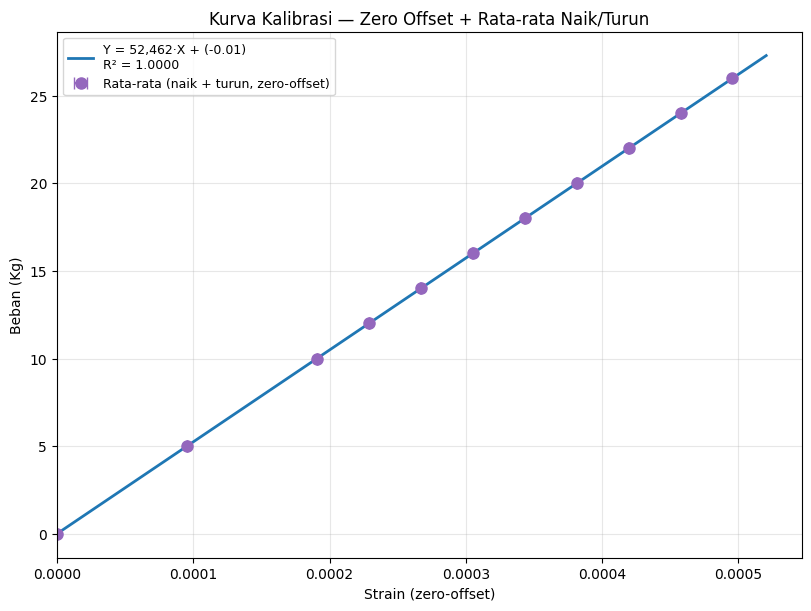


Koefisien tersimpan di dict CALIBRATION_Z: {'m': np.float64(52461.62579602513), 'c': np.float64(-0.0073024498961142825), 'r2': np.float64(0.9999992640953329), 'rmse': np.float64(0.006572164532581556), 'strain_zero': np.float64(8.832003247870486e-05)}


In [39]:
#Cell 3
# =============================================================================
# TUJUAN CELL INI:
# Membuat model kalibrasi yang lebih akurat dengan 2 perbaikan:
#
# 1. ZERO OFFSET
#    Strain saat beban 0 kg dikurangkan dari semua pembacaan.
#    Tujuannya: menghilangkan drift/offset awal sensor, sehingga
#    strain = 0 benar-benar berarti beban = 0 kg.
#
# 2. RATA-RATA NAIK & TURUN
#    Untuk setiap level beban (mis. 10 kg), rata-ratakan strain dari
#    fase naik dan turun. Tujuannya: mengurangi efek histeresis.
#
# 3. REGRESI LINIER
#    Y = m·X + c  (Y = beban kg, X = strain setelah zero-offset)
#    Intercept seharusnya mendekati 0 setelah zero-offset.
#
# Output penting:
# - DataFrame `avg_by_load` (11 titik kalibrasi)
# - Dict `CALIBRATION_Z` (koefisien model final yang direkomendasikan)
# =============================================================================

from scipy import stats

# --- Langkah 1: Zero offset ---
# Ambil strain rata-rata saat beban 0 kg (fase naik) sebagai referensi nol
strain_zero = segments.loc[(segments["load_kg"] == 0) & (segments["phase"] == "naik"), "strain_mean"].iloc[0]
print(f"Strain offset (0 kg, loading): {strain_zero:.6e}")

segments_z = segments.copy()
segments_z["strain_zeroed"] = segments_z["strain_mean"] - strain_zero  # kurangi offset dari semua data

# --- Langkah 2: Rata-rata naik & turun per level beban ---
# Gabungkan 2 pengukuran (naik + turun) menjadi 1 titik per beban
avg_by_load = (
    segments_z.groupby("load_kg", as_index=False)
    .agg(
        strain_mean=("strain_zeroed", "mean"),  # rata-rata strain zero-offset
        strain_std=("strain_zeroed", "std"),    # selisih antara naik & turun (histeresis)
        n_phase=("phase", "count"),             # jumlah fase (harusnya 2, kecuali 0 kg)
    )
    .sort_values("load_kg")
    .reset_index(drop=True)
)

print("\n--- Rata-rata strain (zero-offset) per beban, naik + turun ---")
display(avg_by_load)

# --- Langkah 3: Regresi linier ---
X = avg_by_load["strain_mean"].values  # strain setelah zero-offset
Y = avg_by_load["load_kg"].values      # beban (kg)

slope, intercept, r_value, p_value, std_err = stats.linregress(X, Y)
r_squared = r_value ** 2

avg_by_load["load_pred_kg"] = slope * avg_by_load["strain_mean"] + intercept
avg_by_load["residual_kg"] = avg_by_load["load_kg"] - avg_by_load["load_pred_kg"]
rmse = np.sqrt(np.mean(avg_by_load["residual_kg"] ** 2))

print("\n=== Model Regresi Linier (zero-offset + rata-rata naik/turun) ===")
print(f"Y (Kg) = {slope:.4f} · X (strain) + ({intercept:.4f})")
print(f"m (slope)     : {slope:,.2f} kg/strain")
print(f"c (intercept) : {intercept:.4f} kg")  # seharusnya ~0 setelah zero-offset
print(f"R²            : {r_squared:.6f}")
print(f"RMSE          : {rmse:.4f} kg")
print(f"p-value       : {p_value:.2e}")

display(avg_by_load[["load_kg", "strain_mean", "strain_std", "n_phase",
                     "load_pred_kg", "residual_kg"]])

# --- Plot kurva kalibrasi final ---
fig, ax = plt.subplots(figsize=(8, 6), layout="constrained")

ax.errorbar(
    avg_by_load["strain_mean"], avg_by_load["load_kg"],
    xerr=avg_by_load["strain_std"],
    fmt="o", capsize=4, color="#9467bd", markersize=8,
    label="Rata-rata (naik + turun, zero-offset)",
)

x_fit = np.linspace(0, X.max() * 1.05, 100)  # mulai dari 0 karena sudah zero-offset
y_fit = slope * x_fit + intercept
ax.plot(x_fit, y_fit, "-", color="#1f77b4", linewidth=2,
        label=f"Y = {slope:,.0f}·X + ({intercept:.2f})\nR² = {r_squared:.4f}")

ax.set_xlabel("Strain (zero-offset)")
ax.set_ylabel("Beban (Kg)")
ax.set_xlim(left=0)
ax.set_title("Kurva Kalibrasi — Zero Offset + Rata-rata Naik/Turun")
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)
plt.show()

# Simpan koefisien model final (yang direkomendasikan)
# Rumus prediksi beban:
#   strain_corrected = strain_raw - CALIBRATION_Z["strain_zero"]
#   load_kg = CALIBRATION_Z["m"] * strain_corrected + CALIBRATION_Z["c"]
CALIBRATION_Z = {
    "m": slope,
    "c": intercept,
    "r2": r_squared,
    "rmse": rmse,
    "strain_zero": strain_zero,
}
print(f"\nKoefisien tersimpan di dict CALIBRATION_Z: {CALIBRATION_Z}")
